Published on June 30, 2026. By Prata, Marília (mpwolke)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#Two lines Required to Plot Plotly
import plotly.io as pio
pio.renderers.default = 'iframe'

import plotly.graph_objs as go
import plotly.offline as py
import plotly.express as px

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


#### CVD (cardiovascular disease) although these factors affect everything else.

![](https://media.springernature.com/lw685/springer-static/image/art%3A10.1007%2Fs11883-022-01068-w/MediaObjects/11883_2022_1068_Fig2_HTML.png)https://link.springer.com/article/10.1007/s11883-022-01068-w

## Clustering Students lifestyle risk factors

Lifestyle risk factors of students: A cluster analytical approach

Authors: Lorna J. Dodd, Yahya Al-Nakeeb, Alan Nevill, Mark J. Forshaw

10.1016/j.ypmed.2010.04.005 - https://www.sciencedirect.com/science/article/abs/pii/S0091743510001180

"Unhealthy lifestyle behaviours have been identified as a problem amongst students. This present study investigated the prevalence and clustering of five lifestyle risk factors within a UK Higher Education (HE) institution during the period of April–May in 2008."

"In a cross-sectional design, 410 students completed a ‘health and lifestyle’ survey. Data was collected on psychological stress, physical activity (PA), fruit and vegetable intake, binge drinking, smoking, and demographic factors."

### Results

"Three subgroups emerged from the cluster analysis: ‘unhealthy/high risk’, ‘moderately healthy/moderate risk’ and ‘healthy/low risk’ group. The groups were cross-tabulated by demographics and the resulting clusters provided an insightful indication of how behaviours interact. Data on the whole sample revealed that the prevalence of three lifestyle risk factors were high; 70% did not meet the recommended guidelines of PA, 66% ate less than the recommended servings of fruit and vegetables per day, and 56% reported binge drinking at least once in a seven-day period. Psychological stress was also high amongst the sample, with females experiencing greater psychological stress than males."

"Only 13–32% of university students worldwide meet the recommended guidelines of habitual PA (physical activity). Similar trends in students' dietary intake have also been observed , in fact it has been reported that 18–24 year olds ‘five-a-day’ fruit and vegetable intake is considerably lower than the population as a whole, and it is well documented that a substantial proportion of students partake in excessive alcohol use, and smoking of tobacco." 

"One of the first studies to examine the **clustering of health lifestyle factors** (inactivity, low fruit and vegetable intake, smoking and binge drinking) within this at risk group found that over 95% of German university students did not meet the recommended guidelines for fruit and vegetable intake, 60% did not exercise sufficiently to gain health and wellbeing benefits, 62% reported participation in binge drinking, and 31% of the sample regularly smoked. Demographic differences were noted between males and females: males ate fewer servings of fruit and vegetables per day, smoked more cigarettes per day, consumed more alcoholic drinks per week, and exercised for a longer duration per week." 

"Students' health lifestyles are of concern. The tendency for specific health lifestyle factors to aggregate in clusters has important implications for health promotion within this environment."

https://www.sciencedirect.com/science/article/abs/pii/S0091743510001180

## Competition Citation

@misc{playground-series-s6e7,
    author = {Yao Yan, Walter Reade, Elizabeth Park},
    
    title = {Predicting Student Health Risk},
    year = {2026},
    
    howpublished = {\url{https://kaggle.com/competitions/playground-series-s6e7}},
    note = {Kaggle}
}

## Your Goal: Predicting student health risk.

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')
sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv')

In [3]:
train.tail(3)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


In [6]:
sub.head(2)

,id,health_condition
0,690088,at-risk
1,690089,at-risk


## Target Distribution

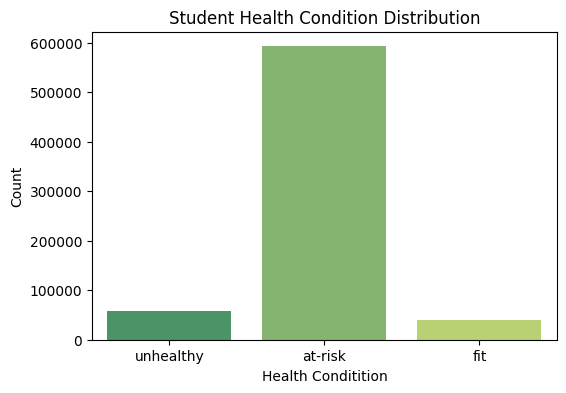

In [8]:
# Plot target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='health_condition', data=train, palette='summer')
plt.title('Student Health Condition Distribution')
plt.xlabel('Health Conditition')
plt.ylabel('Count')
plt.show()

## info () method

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

## Categorical columns

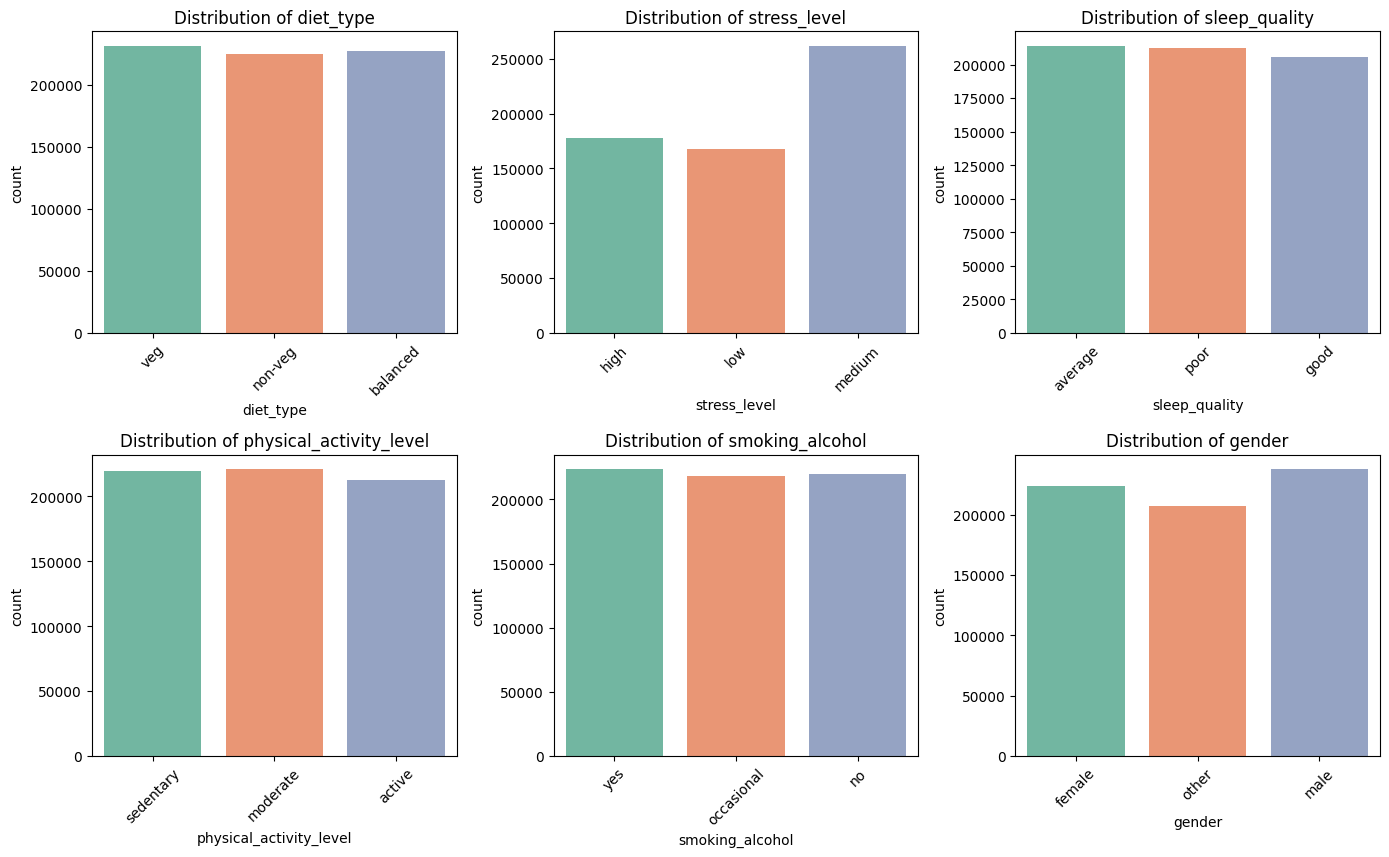

In [11]:
#By H-Z-Ning  https://www.kaggle.com/code/hzning/top-10-solution-0-97525-esay-is-all-you

categorical_columns = ["diet_type", "stress_level", "sleep_quality", "physical_activity_level", "smoking_alcohol", "gender"]

plt.figure(figsize=(14, 12))
for i, column in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=column, data=train, palette='Set2')
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Almost the same results, significant exception: stress_level.

In [12]:
display(train, train.describe(include='all'))

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
count,690088.00000,690088,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000,683187,607277,631757,653467,661506,668715
unique,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3
top,NaN,at-risk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,veg,medium,average,moderate,yes,male
freq,NaN,592561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,231432,261819,213948,221041,223730,237756
mean,345043.50000,NaN,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542,NaN,NaN,NaN,NaN,NaN,NaN
std,199211.39062,NaN,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489,NaN,NaN,NaN,NaN,NaN,NaN
min,0.00000,NaN,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN
25%,172521.75000,NaN,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000,NaN,NaN,NaN,NaN,NaN,NaN
50%,345043.50000,NaN,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000,NaN,NaN,NaN,NaN,NaN,NaN
75%,517565.25000,NaN,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000,NaN,NaN,NaN,NaN,NaN,NaN


## Heatmap

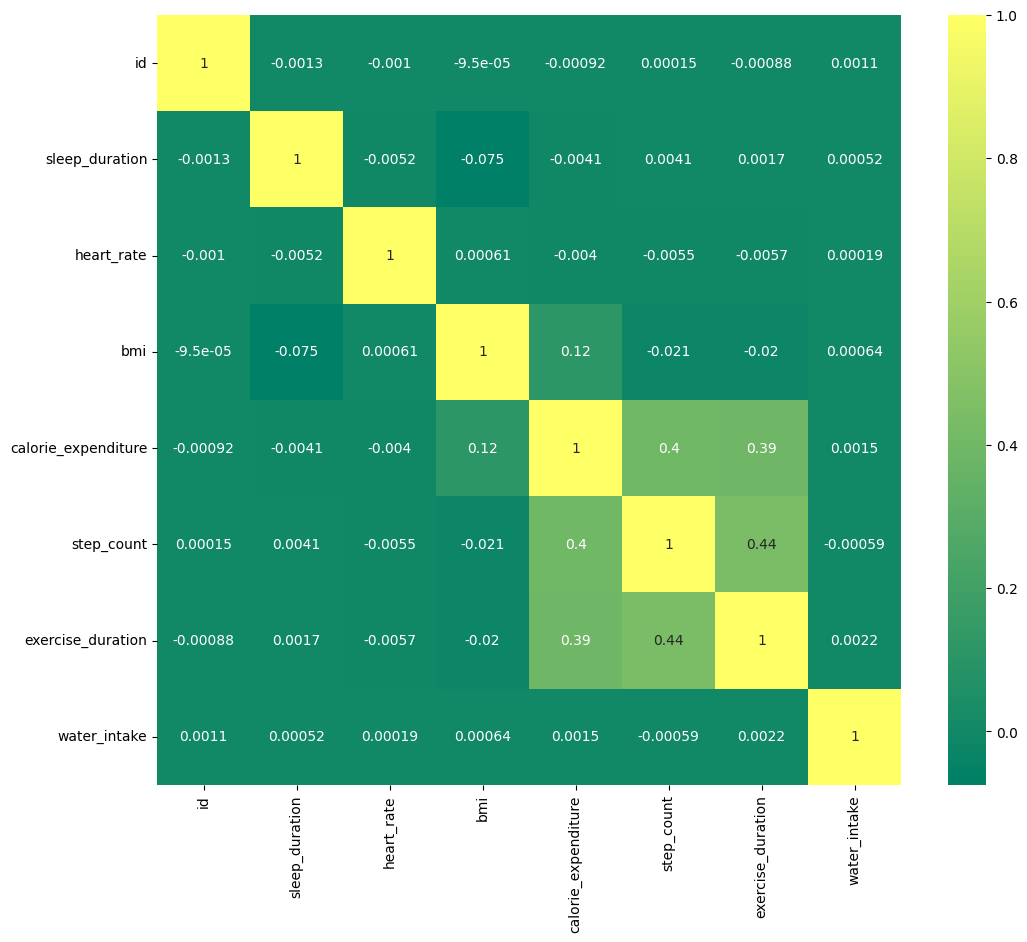

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(train.select_dtypes(include='number').corr(), annot=True, cmap='summer');

## Numerical columns distribution

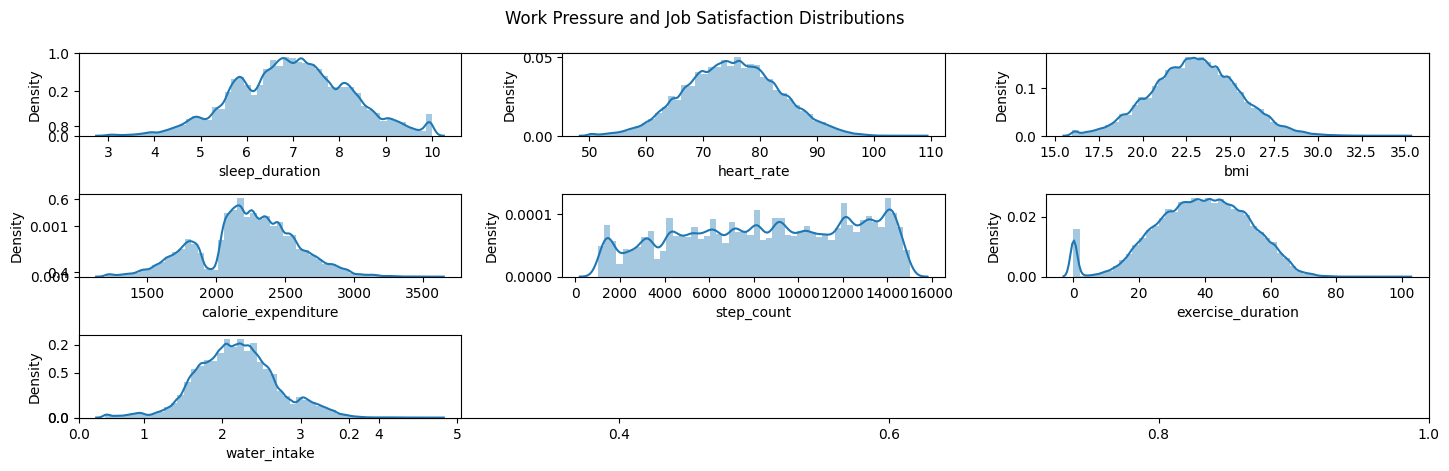

In [14]:
#GeeksForGeeks https://www.geeksforgeeks.org/loan-eligibility-prediction-using-machine-learning-models-in-python/

import seaborn as sb

fig, ax = plt.subplots(figsize=(15, 5))
#plt.subplots(figsize=(15, 5))
fig.suptitle('Work Pressure and Job Satisfaction Distributions')
for i, col in enumerate(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']):
    plt.subplot(3, 3, i+1)
    sb.distplot(train[col])
plt.tight_layout()

plt.show()

## Student Health Condition by Gender

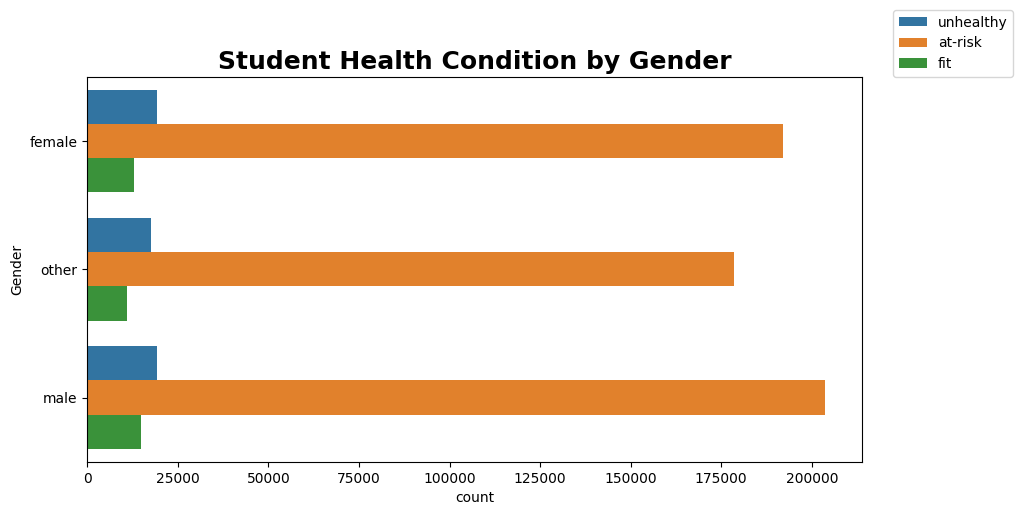

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(y="gender", hue="health_condition", data=train)
plt.title("Student Health Condition by Gender",fontsize=18,fontweight="bold")
plt.legend(loc=(1.04, 1))#StackOverFlow
plt.ylabel("Gender")
plt.show()

### Stress level by gender

It seems that males are a little bit stressed according to this countplot below.

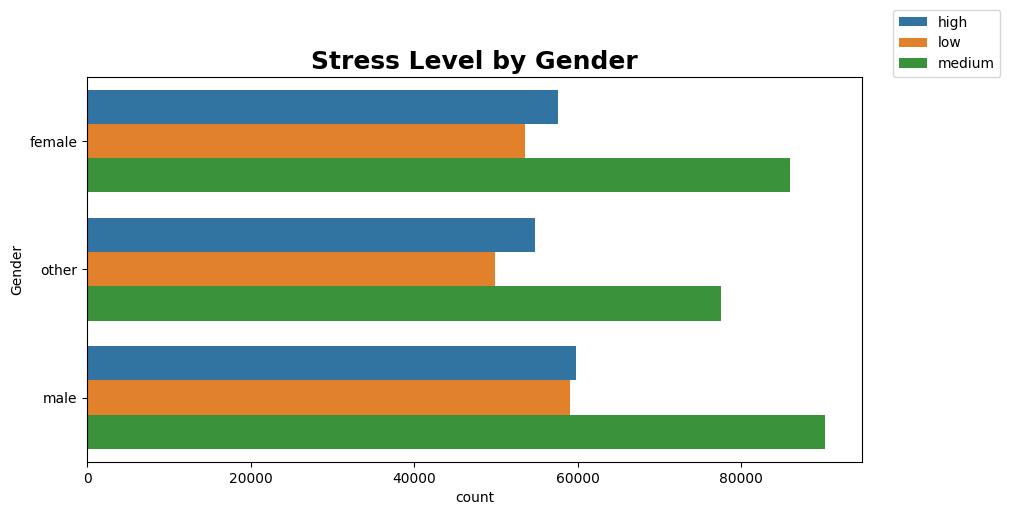

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(y="gender", hue="stress_level", data=train)
plt.title("Stress Level by Gender",fontsize=18,fontweight="bold")
plt.legend(loc=(1.04, 1))#StackOverFlow
plt.ylabel("Gender")
plt.show()

### Diet type by gender

Not a very helpful or even eye-catching Squarify chart : )

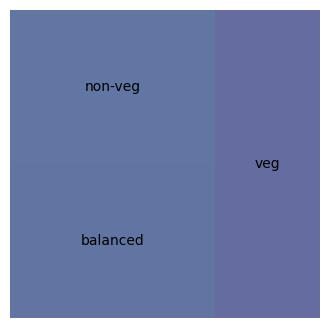

In [18]:
#By Raja CSP https://www.kaggle.com/code/rajacsp/netflix-visualization-plotly-plots-treemap/notebook

import squarify

df_diet_type = train.groupby('diet_type')['gender'].count()

diet_sizes = []
diet_labels = []
for i, v in df_diet_type.items():
    diet_sizes.append(v)
    diet_labels.append(i)
    

fig, ax = plt.subplots(1, figsize = (4,4))
squarify.plot(sizes=diet_sizes, 
              label=diet_labels, 
              alpha=.8 )
plt.axis('off')
plt.show()

## Import Libraries

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [20]:
#By Lalit Sobawane https://www.kaggle.com/code/lalit7881/college-student-health-behavior-eda/notebook

train.columns = train.columns.str.strip()

if 'student_id' in train.columns:
    train = train.drop(columns=['id'])

## Target Encoding

In [21]:
#By Lalit Sobawane https://www.kaggle.com/code/lalit7881/college-student-health-behavior-eda/notebook

target = 'health_condition'

le = LabelEncoder()
train[target] = le.fit_transform(train[target])

X = train.drop(columns=[target])
y = train[target]

### Encode cat columns

In [22]:
#By Lalit Sobawane https://www.kaggle.com/code/lalit7881/college-student-health-behavior-eda/notebook

cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

## train test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scale Numeric columns

In [24]:
#By Lalit Sobawane https://www.kaggle.com/code/lalit7881/college-student-health-behavior-eda/notebook

num_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols)
], remainder='passthrough')

## Model RandomForestClassifier

That's taking a lot of time. I should have written less estimators, since I'm just checking how it works : ) 

In [25]:
#By Lalit Sobawane https://www.kaggle.com/code/lalit7881/college-student-health-behavior-eda/notebook

model = RandomForestClassifier(n_estimators=200)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Train
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

## Metrics

In [26]:
#By Lalit Sobawane https://www.kaggle.com/code/lalit7881/college-student-health-behavior-eda/notebook

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9663159877697112

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98    118512
           1       0.94      0.81      0.87      7961
           2       0.96      0.79      0.87     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.91    138018
weighted avg       0.97      0.97      0.97    138018

Confusion Matrix:
 [[117823    367    322]
 [  1465   6467     29]
 [  2451     15   9079]]


## Binarize target - Plot ROC Curve

Do NOT split these last snippet into "binarize target" and "Random baseline"  otherwise you'll get an awkward ROC curve and two non-sense charts.

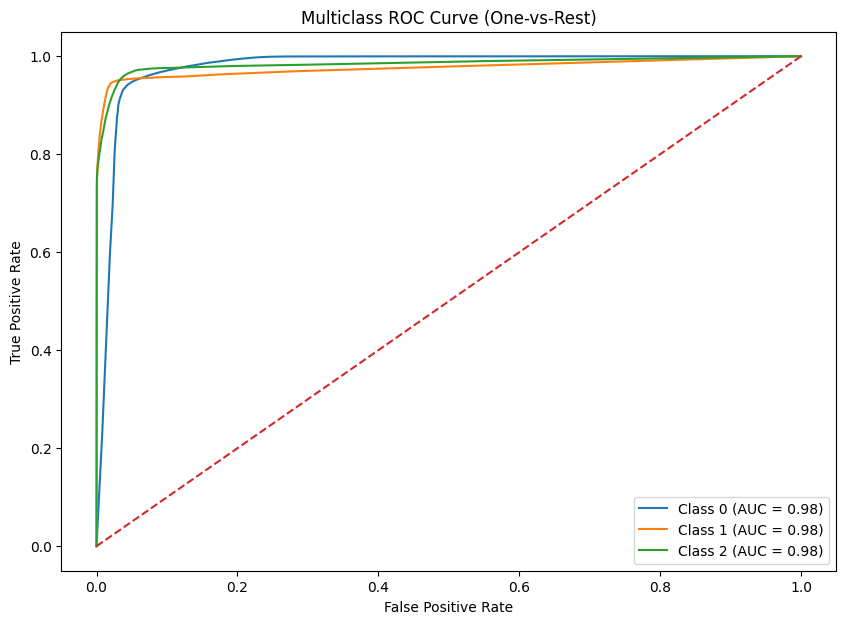

In [29]:
#By Lalit Sobawane https://www.kaggle.com/code/lalit7881/college-student-health-behavior-eda/notebook

# Binarize target
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

## Draft Session: 1h:20min + 55m reading articles and related subjects.

![](https://kidshelpline.com.au/sites/default/files/bdl_image/Header_P_EYPTAFH.png)

## Ask for help. Don't just say that you're Fine.


### The biggest issue to Students health: Silence.

The biggest mental health risk for students isn’t anxiety, depression, or stress.

**It’s silence**.

It’s the student who says, **“I’m fine.”**

The one who keeps their grades up.

The one who still calls home.

The one who has learned how to hide what they’re carrying.

Over half of students who need mental health support never receive it.

Not because they don’t need help.

Because **they don’t ask.**

https://www.instagram.com/reel/DZCo5dyBSyI/

#Acknowledgements:

Lalit Sobawane https://www.kaggle.com/code/lalit7881/college-student-health-behavior-eda/notebook

H-Z-Ning  https://www.kaggle.com/code/hzning/top-10-solution-0-97525-esay-is-all-you

GeeksForGeeks https://www.geeksforgeeks.org/loan-eligibility-prediction-using-machine-learning-models-in-python/